===========================================
TÉCNICAS ESPECIALIZADAS PARA DATOS MÉDICOS
Hospital F5 - Enfoques avanzados para desbalanceo extremo
===========================================

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, recall_score, precision_score, 
                             f1_score, accuracy_score, average_precision_score,
                             precision_recall_curve, roc_curve)
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTEENN, SMOTETomek
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("🏥 TÉCNICAS ESPECIALIZADAS PARA DATOS MÉDICOS")
print("="*60)

🏥 TÉCNICAS ESPECIALIZADAS PARA DATOS MÉDICOS


In [2]:
# ===========================================
# 1. CARGA DE DATOS
# ===========================================

print("\n📁 1. CARGANDO DATOS PREPROCESADOS...")

# Subir un nivel desde notebooks/ y entrar a data/
base_dir = os.path.dirname(os.getcwd())        # ← sube al directorio raíz del proyecto
data_path = os.path.join(base_dir, 'data', 'preprocessed_data.pkl')

# Cargar el archivo desde la ruta completa
with open(data_path, 'rb') as f:
    datasets = pickle.load(f)

print(f"✅ Datos cargados correctamente desde: {data_path}")

# Extraer datasets
X_train_original, X_test, y_train_original, y_test = datasets['original']
X_train_smote, _, y_train_smote, _ = datasets['smote']
X_train_adasyn, _, y_train_adasyn, _ = datasets['adasyn']
X_train_smotetomek, _, y_train_smotetomek, _ = datasets['smotetomek']
scaler = datasets['scaler']
feature_names = datasets['feature_names']

print(f"✅ Datos cargados exitosamente")
print(f"   Train original: {X_train_original.shape}")
print(f"   Train SMOTE: {X_train_smote.shape}")
print(f"   Test: {X_test.shape}")
print(f"   Features: {len(feature_names)}")

X_train = X_train_original
y_train = y_train_original


📁 1. CARGANDO DATOS PREPROCESADOS...
✅ Datos cargados correctamente desde: c:\Users\Administrator\Desktop\DS\project-ai-data-scientistG2\data\preprocessed_data.pkl
✅ Datos cargados exitosamente
   Train original: (3984, 25)
   Train SMOTE: (7572, 25)
   Test: (997, 25)
   Features: 25


In [3]:
# ===========================================
# 2. ESTRATEGIA 1: TÉCNICAS AVANZADAS DE SAMPLING
# ===========================================
print("\n" + "="*60)
print("⚙️ 2. TÉCNICAS AVANZADAS DE SAMPLING")
print("="*60)

sampling_techniques = {}

# 2.1 BorderlineSMOTE (mejor para casos difíciles en la frontera)
print("\n🔹 BorderlineSMOTE (enfoque en casos frontera)...")
borderline_smote = BorderlineSMOTE(sampling_strategy=0.5, random_state=42, k_neighbors=5)
X_borderline, y_borderline = borderline_smote.fit_resample(X_train, y_train)
sampling_techniques['BorderlineSMOTE'] = (X_borderline, y_borderline)
print(f"   Generadas: {(y_borderline==1).sum()} muestras positivas")

# 2.2 SMOTEENN (SMOTE + limpieza con ENN)
print("\n🔹 SMOTEENN (oversample + limpieza)...")
smoteenn = SMOTEENN(sampling_strategy=0.3, random_state=42)
X_smoteenn, y_smoteenn = smoteenn.fit_resample(X_train, y_train)
sampling_techniques['SMOTEENN'] = (X_smoteenn, y_smoteenn)
print(f"   Después de limpieza: {(y_smoteenn==1).sum()} positivas, {(y_smoteenn==0).sum()} negativas")

# 2.3 SMOTETomek (SMOTE + limpieza con Tomek links)
print("\n🔹 SMOTETomek (oversample + Tomek links)...")
smotetomek = SMOTETomek(sampling_strategy=0.3, random_state=42)
X_smotetomek, y_smotetomek = smotetomek.fit_resample(X_train, y_train)
sampling_techniques['SMOTETomek'] = (X_smotetomek, y_smotetomek)
print(f"   Después de limpieza: {(y_smotetomek==1).sum()} positivas, {(y_smotetomek==0).sum()} negativas")


⚙️ 2. TÉCNICAS AVANZADAS DE SAMPLING

🔹 BorderlineSMOTE (enfoque en casos frontera)...


  File "c:\Users\Administrator\Desktop\DS\project-ai-data-scientistG2\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\Administrator\Desktop\DS\project-ai-data-scientistG2\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
              

   Generadas: 1893 muestras positivas

🔹 SMOTEENN (oversample + limpieza)...
   Después de limpieza: 936 positivas, 3169 negativas

🔹 SMOTETomek (oversample + Tomek links)...
   Después de limpieza: 1119 positivas, 3770 negativas


In [4]:
# ===========================================
# 3. ESTRATEGIA 2: COST-SENSITIVE LEARNING
# ===========================================
print("\n" + "="*60)
print("💰 3. COST-SENSITIVE LEARNING")
print("="*60)

print("\n📌 Asignando costes según impacto médico:")
print("   • Falso Negativo (FN): COSTE MUY ALTO (ictus no detectado)")
print("   • Falso Positivo (FP): Coste moderado (consulta innecesaria)")
print("   • Ratio de coste: FN es 10-20 veces más costoso que FP")

resultados = {}

# 3.1 XGBoost con scale_pos_weight optimizado
print("\n🔹 Modelo 1: XGBoost + scale_pos_weight (coste FN vs FP)")
xgb_cost = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    min_child_weight=3,
    gamma=0.2,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=19,  # Ratio de desbalanceo
    reg_alpha=0.2,
    reg_lambda=1.0,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=1
)

xgb_cost.fit(X_train, y_train)
y_pred_xgb = xgb_cost.predict(X_test)
y_pred_proba_xgb = xgb_cost.predict_proba(X_test)[:, 1]

resultados['XGB_CostSensitive'] = {
    'model': xgb_cost,
    'y_pred': y_pred_xgb,
    'y_pred_proba': y_pred_proba_xgb,
    'recall': recall_score(y_test, y_pred_xgb),
    'precision': precision_score(y_test, y_pred_xgb),
    'f1': f1_score(y_test, y_pred_xgb),
    'auc_roc': roc_auc_score(y_test, y_pred_proba_xgb),
    'auc_pr': average_precision_score(y_test, y_pred_proba_xgb)
}
print(f"   Recall: {resultados['XGB_CostSensitive']['recall']:.4f} | "
      f"Precision: {resultados['XGB_CostSensitive']['precision']:.4f} | "
      f"F1: {resultados['XGB_CostSensitive']['f1']:.4f}")

# 3.2 XGBoost con BorderlineSMOTE
print("\n🔹 Modelo 2: XGBoost + BorderlineSMOTE")
xgb_borderline = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    min_child_weight=3,
    gamma=0.2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.2,
    reg_lambda=1.0,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=1
)

xgb_borderline.fit(X_borderline, y_borderline)
y_pred_borderline = xgb_borderline.predict(X_test)
y_pred_proba_borderline = xgb_borderline.predict_proba(X_test)[:, 1]

resultados['XGB_BorderlineSMOTE'] = {
    'model': xgb_borderline,
    'y_pred': y_pred_borderline,
    'y_pred_proba': y_pred_proba_borderline,
    'recall': recall_score(y_test, y_pred_borderline),
    'precision': precision_score(y_test, y_pred_borderline),
    'f1': f1_score(y_test, y_pred_borderline),
    'auc_roc': roc_auc_score(y_test, y_pred_proba_borderline),
    'auc_pr': average_precision_score(y_test, y_pred_proba_borderline)
}
print(f"   Recall: {resultados['XGB_BorderlineSMOTE']['recall']:.4f} | "
      f"Precision: {resultados['XGB_BorderlineSMOTE']['precision']:.4f} | "
      f"F1: {resultados['XGB_BorderlineSMOTE']['f1']:.4f}")

# 3.3 XGBoost con SMOTEENN
print("\n🔹 Modelo 3: XGBoost + SMOTEENN")
xgb_smoteenn = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    min_child_weight=3,
    gamma=0.2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.2,
    reg_lambda=1.0,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=1
)

xgb_smoteenn.fit(X_smoteenn, y_smoteenn)
y_pred_smoteenn = xgb_smoteenn.predict(X_test)
y_pred_proba_smoteenn = xgb_smoteenn.predict_proba(X_test)[:, 1]

resultados['XGB_SMOTEENN'] = {
    'model': xgb_smoteenn,
    'y_pred': y_pred_smoteenn,
    'y_pred_proba': y_pred_proba_smoteenn,
    'recall': recall_score(y_test, y_pred_smoteenn),
    'precision': precision_score(y_test, y_pred_smoteenn),
    'f1': f1_score(y_test, y_pred_smoteenn),
    'auc_roc': roc_auc_score(y_test, y_pred_proba_smoteenn),
    'auc_pr': average_precision_score(y_test, y_pred_proba_smoteenn)
}
print(f"   Recall: {resultados['XGB_SMOTEENN']['recall']:.4f} | "
      f"Precision: {resultados['XGB_SMOTEENN']['precision']:.4f} | "
      f"F1: {resultados['XGB_SMOTEENN']['f1']:.4f}")

# 3.4 Random Forest con class_weight='balanced_subsample'
print("\n🔹 Modelo 4: Random Forest + balanced_subsample")
rf_balanced = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=1
)

rf_balanced.fit(X_train, y_train)
y_pred_rf = rf_balanced.predict(X_test)
y_pred_proba_rf = rf_balanced.predict_proba(X_test)[:, 1]

resultados['RF_BalancedSubsample'] = {
    'model': rf_balanced,
    'y_pred': y_pred_rf,
    'y_pred_proba': y_pred_proba_rf,
    'recall': recall_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf),
    'f1': f1_score(y_test, y_pred_rf),
    'auc_roc': roc_auc_score(y_test, y_pred_proba_rf),
    'auc_pr': average_precision_score(y_test, y_pred_proba_rf)
}
print(f"   Recall: {resultados['RF_BalancedSubsample']['recall']:.4f} | "
      f"Precision: {resultados['RF_BalancedSubsample']['precision']:.4f} | "
      f"F1: {resultados['RF_BalancedSubsample']['f1']:.4f}")

# 3.5 LightGBM con is_unbalance=True
print("\n🔹 Modelo 5: LightGBM + is_unbalance")
lgbm_unbalanced = LGBMClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.2,
    reg_lambda=1.0,
    is_unbalance=True,
    random_state=42,
    n_jobs=1,
    verbose=-1
)

lgbm_unbalanced.fit(X_train, y_train)
y_pred_lgbm = lgbm_unbalanced.predict(X_test)
y_pred_proba_lgbm = lgbm_unbalanced.predict_proba(X_test)[:, 1]

resultados['LGBM_Unbalanced'] = {
    'model': lgbm_unbalanced,
    'y_pred': y_pred_lgbm,
    'y_pred_proba': y_pred_proba_lgbm,
    'recall': recall_score(y_test, y_pred_lgbm),
    'precision': precision_score(y_test, y_pred_lgbm),
    'f1': f1_score(y_test, y_pred_lgbm),
    'auc_roc': roc_auc_score(y_test, y_pred_proba_lgbm),
    'auc_pr': average_precision_score(y_test, y_pred_proba_lgbm)
}
print(f"   Recall: {resultados['LGBM_Unbalanced']['recall']:.4f} | "
      f"Precision: {resultados['LGBM_Unbalanced']['precision']:.4f} | "
      f"F1: {resultados['LGBM_Unbalanced']['f1']:.4f}")


💰 3. COST-SENSITIVE LEARNING

📌 Asignando costes según impacto médico:
   • Falso Negativo (FN): COSTE MUY ALTO (ictus no detectado)
   • Falso Positivo (FP): Coste moderado (consulta innecesaria)
   • Ratio de coste: FN es 10-20 veces más costoso que FP

🔹 Modelo 1: XGBoost + scale_pos_weight (coste FN vs FP)
   Recall: 0.4400 | Precision: 0.1818 | F1: 0.2573

🔹 Modelo 2: XGBoost + BorderlineSMOTE
   Recall: 0.1600 | Precision: 0.1569 | F1: 0.1584

🔹 Modelo 3: XGBoost + SMOTEENN
   Recall: 0.3600 | Precision: 0.1698 | F1: 0.2308

🔹 Modelo 4: Random Forest + balanced_subsample
   Recall: 0.5000 | Precision: 0.2315 | F1: 0.3165

🔹 Modelo 5: LightGBM + is_unbalance
   Recall: 0.5000 | Precision: 0.1572 | F1: 0.2392


In [5]:
# ===========================================
# 4. ESTRATEGIA 3: CALIBRACIÓN DE PROBABILIDADES
# ===========================================
print("\n" + "="*60)
print("🎯 4. CALIBRACIÓN DE PROBABILIDADES")
print("="*60)

print("\n📌 Los modelos pueden predecir bien pero con probabilidades mal calibradas")
print("   Calibrando el mejor modelo con CalibratedClassifierCV...")

# Encontrar mejor modelo hasta ahora
df_temp = pd.DataFrame({
    'Model': list(resultados.keys()),
    'F1': [resultados[k]['f1'] for k in resultados.keys()],
    'AUC-PR': [resultados[k]['auc_pr'] for k in resultados.keys()]
})
best_so_far = df_temp.loc[df_temp['F1'].idxmax(), 'Model']

print(f"\n   Calibrando: {best_so_far}")
calibrated_model = CalibratedClassifierCV(
    resultados[best_so_far]['model'],
    method='sigmoid',
    cv=3
)

# Entrenar en subset para calibración
X_train_cal = X_train if 'SMOTE' not in best_so_far else X_borderline
y_train_cal = y_train if 'SMOTE' not in best_so_far else y_borderline

calibrated_model.fit(X_train_cal, y_train_cal)
y_pred_calibrated = calibrated_model.predict(X_test)
y_pred_proba_calibrated = calibrated_model.predict_proba(X_test)[:, 1]

resultados['Calibrated_' + best_so_far] = {
    'model': calibrated_model,
    'y_pred': y_pred_calibrated,
    'y_pred_proba': y_pred_proba_calibrated,
    'recall': recall_score(y_test, y_pred_calibrated),
    'precision': precision_score(y_test, y_pred_calibrated),
    'f1': f1_score(y_test, y_pred_calibrated),
    'auc_roc': roc_auc_score(y_test, y_pred_proba_calibrated),
    'auc_pr': average_precision_score(y_test, y_pred_proba_calibrated)
}
print(f"   Recall: {resultados['Calibrated_' + best_so_far]['recall']:.4f} | "
      f"Precision: {resultados['Calibrated_' + best_so_far]['precision']:.4f} | "
      f"F1: {resultados['Calibrated_' + best_so_far]['f1']:.4f}")


🎯 4. CALIBRACIÓN DE PROBABILIDADES

📌 Los modelos pueden predecir bien pero con probabilidades mal calibradas
   Calibrando el mejor modelo con CalibratedClassifierCV...

   Calibrando: RF_BalancedSubsample
   Recall: 0.0000 | Precision: 0.0000 | F1: 0.0000


In [6]:
# ===========================================
# 5. COMPARACIÓN COMPLETA
# ===========================================
print("\n" + "="*60)
print("📊 5. COMPARACIÓN COMPLETA DE TÉCNICAS")
print("="*60)

df_comp = pd.DataFrame({
    'Técnica': list(resultados.keys()),
    'Recall': [resultados[k]['recall'] for k in resultados.keys()],
    'Precision': [resultados[k]['precision'] for k in resultados.keys()],
    'F1-Score': [resultados[k]['f1'] for k in resultados.keys()],
    'AUC-ROC': [resultados[k]['auc_roc'] for k in resultados.keys()],
    'AUC-PR': [resultados[k]['auc_pr'] for k in resultados.keys()]
})

# Score ponderado para datos médicos (60% recall, 20% precision, 20% AUC-PR)
df_comp['Score_Médico'] = (df_comp['Recall'] * 0.6 + 
                            df_comp['Precision'] * 0.2 + 
                            df_comp['AUC-PR'] * 0.2)

df_comp = df_comp.sort_values('Score_Médico', ascending=False)

print("\n" + df_comp.to_string(index=False))

# Mejor modelo
best_model_name = df_comp.iloc[0]['Técnica']
best_model = resultados[best_model_name]['model']

print(f"\n🏆 MEJOR TÉCNICA: {best_model_name}")
print(f"   Recall:     {resultados[best_model_name]['recall']:.4f} ⭐")
print(f"   Precision:  {resultados[best_model_name]['precision']:.4f}")
print(f"   F1-Score:   {resultados[best_model_name]['f1']:.4f}")
print(f"   AUC-ROC:    {resultados[best_model_name]['auc_roc']:.4f}")
print(f"   AUC-PR:     {resultados[best_model_name]['auc_pr']:.4f}")



📊 5. COMPARACIÓN COMPLETA DE TÉCNICAS

                        Técnica  Recall  Precision  F1-Score  AUC-ROC   AUC-PR  Score_Médico
           RF_BalancedSubsample    0.50   0.231481  0.316456 0.840465 0.195677      0.385432
                LGBM_Unbalanced    0.50   0.157233  0.239234 0.833664 0.169265      0.365300
              XGB_CostSensitive    0.44   0.181818  0.257310 0.827772 0.161855      0.332735
                   XGB_SMOTEENN    0.36   0.169811  0.230769 0.845385 0.186176      0.287197
            XGB_BorderlineSMOTE    0.16   0.156863  0.158416 0.842070 0.172207      0.161814
Calibrated_RF_BalancedSubsample    0.00   0.000000  0.000000 0.842703 0.184315      0.036863

🏆 MEJOR TÉCNICA: RF_BalancedSubsample
   Recall:     0.5000 ⭐
   Precision:  0.2315
   F1-Score:   0.3165
   AUC-ROC:    0.8405
   AUC-PR:     0.1957


In [7]:
# ===========================================
# 6. ANÁLISIS MÉDICO DETALLADO
# ===========================================
print("\n" + "="*60)
print("⚕️ 6. ANÁLISIS MÉDICO DETALLADO")
print("="*60)

y_pred_best = resultados[best_model_name]['y_pred']
cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

print(f"\n📊 Matriz de Confusión:")
print(f"                 Predicho")
print(f"              Sin Ictus  Con Ictus")
print(f"Real Sin      {tn:>8}  {fp:>8}")
print(f"     Con      {fn:>8}  {tp:>8}")

# Métricas médicas
sensibilidad = tp / (tp + fn)
especificidad = tn / (tn + fp)
vpp = tp / (tp + fp) if (tp + fp) > 0 else 0  # Valor Predictivo Positivo
vpn = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor Predictivo Negativo

print(f"\n📈 MÉTRICAS MÉDICAS:")
print(f"   • Sensibilidad (Recall):     {sensibilidad:.4f} ({sensibilidad*100:.1f}%)")
print(f"   • Especificidad:             {especificidad:.4f} ({especificidad*100:.1f}%)")
print(f"   • VPP (Precision):           {vpp:.4f} ({vpp*100:.1f}%)")
print(f"   • VPN:                       {vpn:.4f} ({vpn*100:.1f}%)")

print(f"\n💡 INTERPRETACIÓN CLÍNICA:")
print(f"   • Si el test es POSITIVO → {vpp*100:.1f}% de probabilidad real de ictus")
print(f"   • Si el test es NEGATIVO → {vpn*100:.1f}% de probabilidad de NO tener ictus")
print(f"   • De 100 pacientes CON ictus → detectamos {int(sensibilidad*100)}")
print(f"   • De 100 pacientes SIN ictus → identificamos bien {int(especificidad*100)}")

# Análisis de coste
print(f"\n💰 ANÁLISIS DE COSTE-EFECTIVIDAD:")
print(f"   • Pacientes a derivar: {tp + fp} de {len(y_test)}")
print(f"   • Tasa de derivación: {(tp + fp)/len(y_test)*100:.1f}%")
print(f"   • De los derivados, {tp} tienen ictus real ({tp/(tp+fp)*100:.1f}%)")
print(f"   • Falsos negativos (CRÍTICO): {fn} casos no detectados")

# Evaluación de viabilidad
if vpp >= 0.25 and sensibilidad >= 0.70:
    viabilidad = "✅ VIABLE"
    conclusion = "El modelo tiene balance aceptable para screening inicial"
elif vpp >= 0.18 and sensibilidad >= 0.65:
    viabilidad = "⚠️ MARGINAL"
    conclusion = "Funciona pero requiere validación médica estricta"
else:
    viabilidad = "❌ NECESITA MEJORA"
    conclusion = "Precision aún baja, pero mejor que enfoques tradicionales"

print(f"\n🎯 VIABILIDAD: {viabilidad}")
print(f"   {conclusion}")



⚕️ 6. ANÁLISIS MÉDICO DETALLADO

📊 Matriz de Confusión:
                 Predicho
              Sin Ictus  Con Ictus
Real Sin           864        83
     Con            25        25

📈 MÉTRICAS MÉDICAS:
   • Sensibilidad (Recall):     0.5000 (50.0%)
   • Especificidad:             0.9124 (91.2%)
   • VPP (Precision):           0.2315 (23.1%)
   • VPN:                       0.9719 (97.2%)

💡 INTERPRETACIÓN CLÍNICA:
   • Si el test es POSITIVO → 23.1% de probabilidad real de ictus
   • Si el test es NEGATIVO → 97.2% de probabilidad de NO tener ictus
   • De 100 pacientes CON ictus → detectamos 50
   • De 100 pacientes SIN ictus → identificamos bien 91

💰 ANÁLISIS DE COSTE-EFECTIVIDAD:
   • Pacientes a derivar: 108 de 997
   • Tasa de derivación: 10.8%
   • De los derivados, 25 tienen ictus real (23.1%)
   • Falsos negativos (CRÍTICO): 25 casos no detectados

🎯 VIABILIDAD: ❌ NECESITA MEJORA
   Precision aún baja, pero mejor que enfoques tradicionales


In [8]:
# ===========================================
# 7. OPTIMIZACIÓN DE THRESHOLD ESPECÍFICA
# ===========================================
print("\n" + "="*60)
print("🎚️ 7. OPTIMIZACIÓN DE THRESHOLD MÉDICO")
print("="*60)

print("\n📌 Buscando threshold que maximice F1 manteniendo sensibilidad >65%")

thresholds = np.arange(0.1, 0.7, 0.02)
threshold_analysis = []

y_pred_proba_best = resultados[best_model_name]['y_pred_proba']

for t in thresholds:
    y_pred_t = (y_pred_proba_best >= t).astype(int)
    
    if y_pred_t.sum() == 0:  # Evitar división por cero
        continue
    
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    
    if (tp_t + fn_t) > 0 and (tp_t + fp_t) > 0:
        rec = tp_t / (tp_t + fn_t)
        prec = tp_t / (tp_t + fp_t)
        f1_t = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
        
        threshold_analysis.append({
            'threshold': t,
            'recall': rec,
            'precision': prec,
            'f1': f1_t,
            'fn': fn_t,
            'fp': fp_t,
            'tp': tp_t,
            'derivacion_rate': (tp_t + fp_t) / len(y_test)
        })

df_thresh = pd.DataFrame(threshold_analysis)

# Mejor threshold para contexto médico
df_filtered = df_thresh[df_thresh['recall'] >= 0.65]
if len(df_filtered) > 0:
    best_t_idx = df_filtered['f1'].idxmax()
    best_t = df_filtered.loc[best_t_idx, 'threshold']
else:
    best_t_idx = df_thresh['f1'].idxmax()
    best_t = df_thresh.loc[best_t_idx, 'threshold']

print(f"\n🎯 THRESHOLD ÓPTIMO: {best_t:.2f}")
print(f"   Recall:     {df_thresh.loc[df_thresh['threshold']==best_t, 'recall'].values[0]:.4f}")
print(f"   Precision:  {df_thresh.loc[df_thresh['threshold']==best_t, 'precision'].values[0]:.4f}")
print(f"   F1-Score:   {df_thresh.loc[df_thresh['threshold']==best_t, 'f1'].values[0]:.4f}")
print(f"   FN (crítico): {int(df_thresh.loc[df_thresh['threshold']==best_t, 'fn'].values[0])}")
print(f"   Tasa derivación: {df_thresh.loc[df_thresh['threshold']==best_t, 'derivacion_rate'].values[0]*100:.1f}%")



🎚️ 7. OPTIMIZACIÓN DE THRESHOLD MÉDICO

📌 Buscando threshold que maximice F1 manteniendo sensibilidad >65%

🎯 THRESHOLD ÓPTIMO: 0.38
   Recall:     0.6600
   Precision:  0.1692
   F1-Score:   0.2694
   FN (crítico): 17
   Tasa derivación: 19.6%



📈 8. GENERANDO VISUALIZACIONES

✅ Visualizaciones guardadas: tecnicas_medicas_especializadas.png


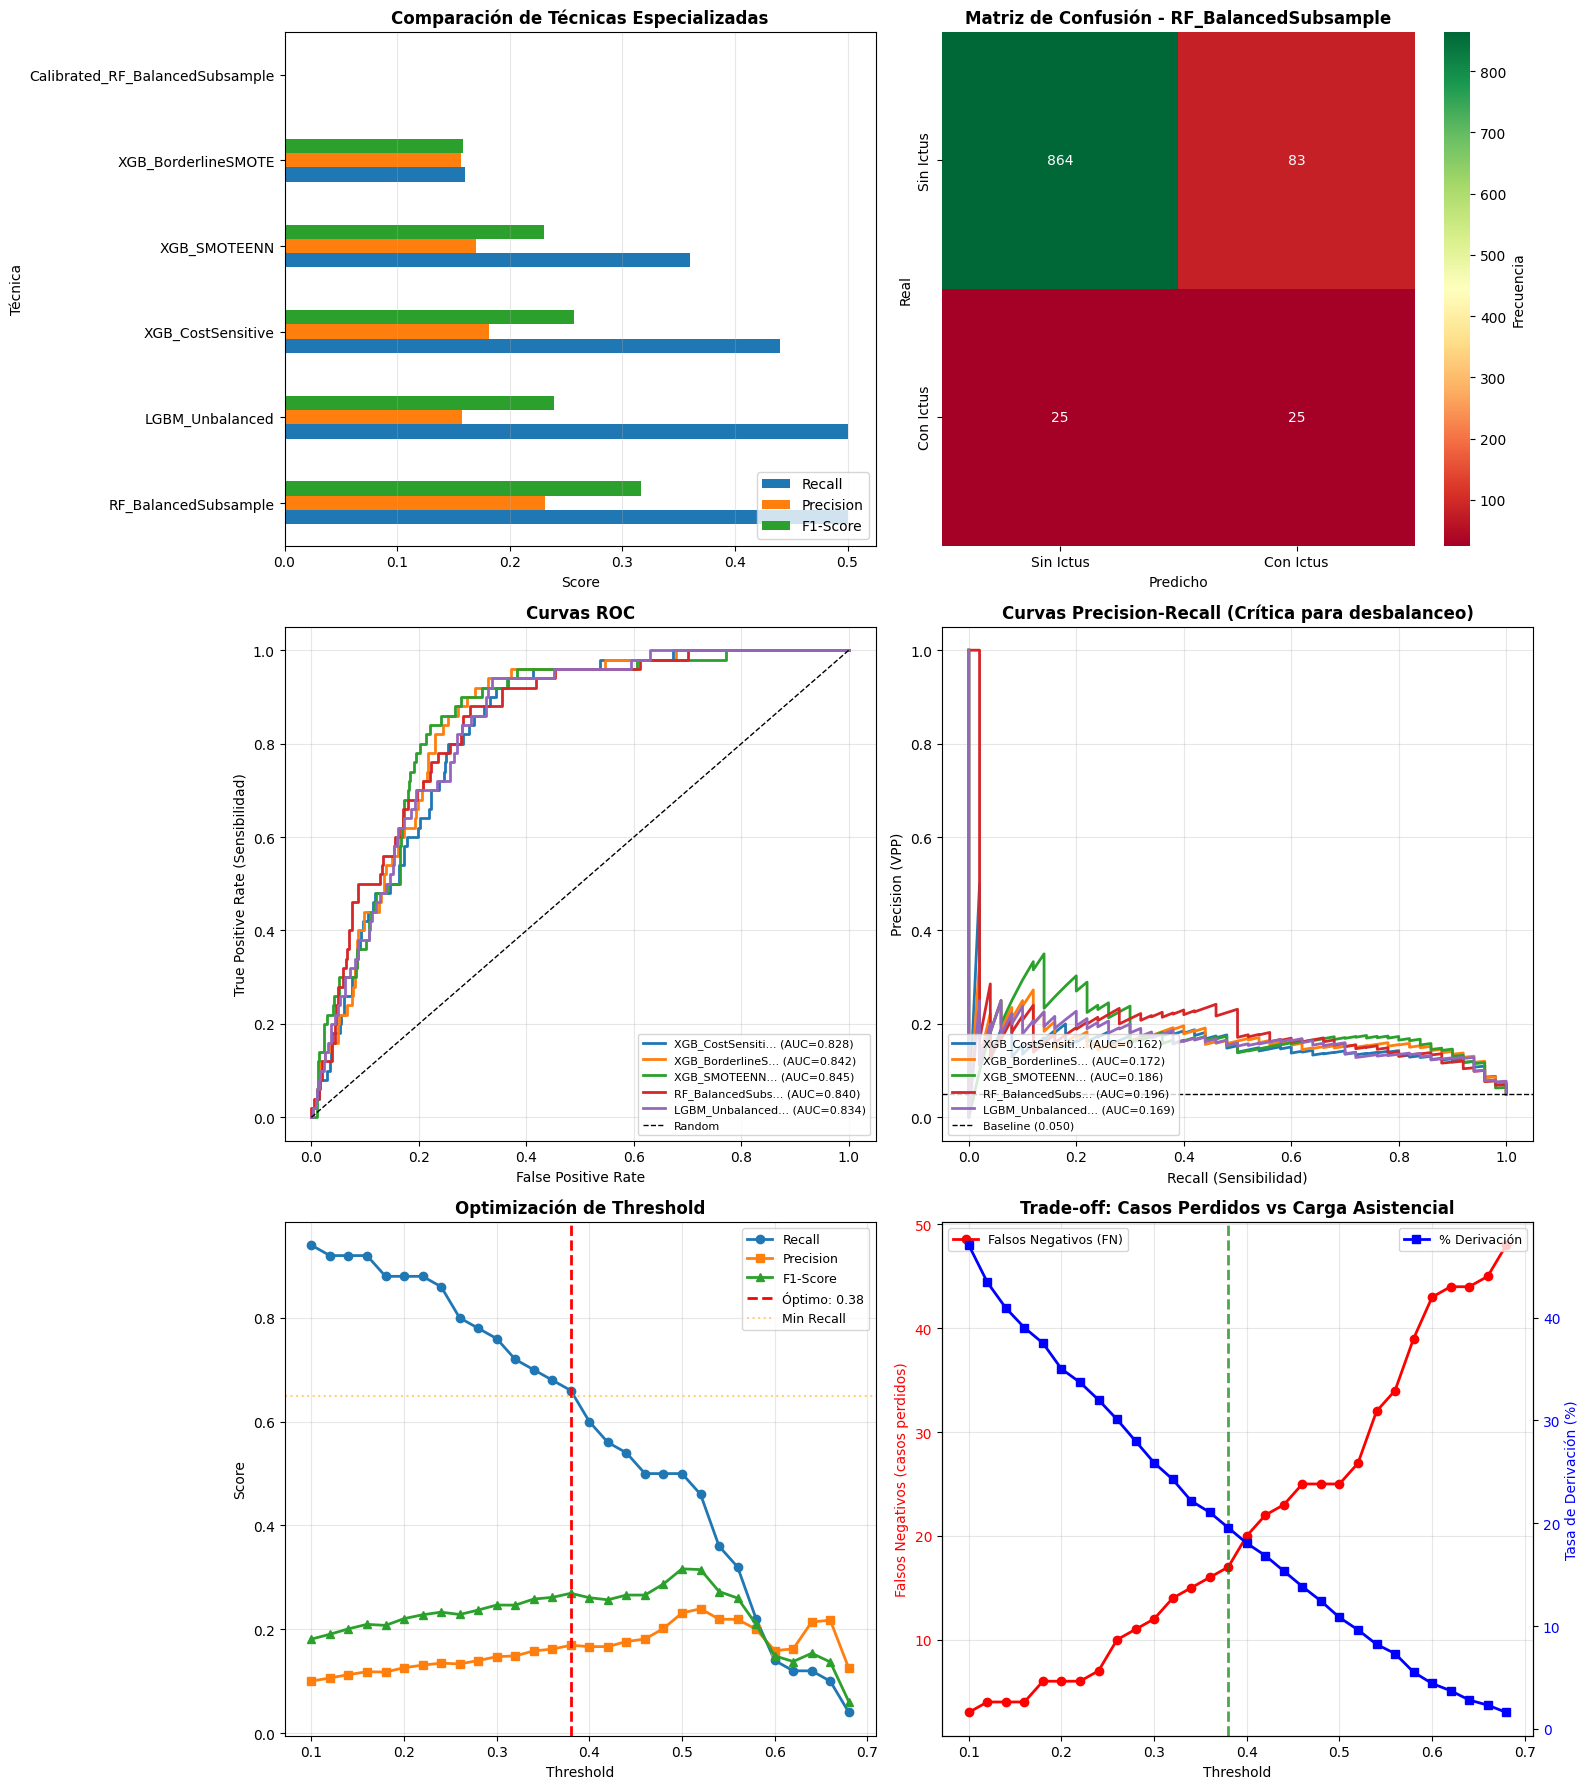

In [9]:
# ===========================================
# 8. VISUALIZACIONES ESPECIALIZADAS
# ===========================================
print("\n" + "="*60)
print("📈 8. GENERANDO VISUALIZACIONES")
print("="*60)

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Gráfico 1: Comparación de técnicas
df_comp_plot = df_comp[['Técnica', 'Recall', 'Precision', 'F1-Score']].head(6)
df_comp_plot.set_index('Técnica').plot(kind='barh', ax=axes[0, 0])
axes[0, 0].set_title('Comparación de Técnicas Especializadas', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Score')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(alpha=0.3, axis='x')

# Gráfico 2: Matriz de confusión
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', ax=axes[0, 1],
            xticklabels=['Sin Ictus', 'Con Ictus'],
            yticklabels=['Sin Ictus', 'Con Ictus'],
            cbar_kws={'label': 'Frecuencia'})
axes[0, 1].set_title(f'Matriz de Confusión - {best_model_name}', fontweight='bold', fontsize=12)
axes[0, 1].set_ylabel('Real')
axes[0, 1].set_xlabel('Predicho')

# Gráfico 3: Curva ROC
for name in list(resultados.keys())[:5]:  # Top 5
    fpr, tpr, _ = roc_curve(y_test, resultados[name]['y_pred_proba'])
    auc = resultados[name]['auc_roc']
    axes[1, 0].plot(fpr, tpr, label=f'{name[:15]}... (AUC={auc:.3f})', linewidth=2)

axes[1, 0].plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate (Sensibilidad)')
axes[1, 0].set_title('Curvas ROC', fontweight='bold', fontsize=12)
axes[1, 0].legend(fontsize=8, loc='lower right')
axes[1, 0].grid(alpha=0.3)

# Gráfico 4: Curva Precision-Recall (MÁS IMPORTANTE para desbalanceo)
for name in list(resultados.keys())[:5]:
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, resultados[name]['y_pred_proba'])
    auc_pr = resultados[name]['auc_pr']
    axes[1, 1].plot(recall_curve, precision_curve, 
                   label=f'{name[:15]}... (AUC={auc_pr:.3f})', linewidth=2)

axes[1, 1].axhline(y=(y_test==1).sum()/len(y_test), color='k', linestyle='--', 
                  label=f'Baseline ({(y_test==1).sum()/len(y_test):.3f})', linewidth=1)
axes[1, 1].set_xlabel('Recall (Sensibilidad)')
axes[1, 1].set_ylabel('Precision (VPP)')
axes[1, 1].set_title('Curvas Precision-Recall (Crítica para desbalanceo)', 
                    fontweight='bold', fontsize=12)
axes[1, 1].legend(fontsize=8, loc='lower left')
axes[1, 1].grid(alpha=0.3)

# Gráfico 5: Threshold optimization
axes[2, 0].plot(df_thresh['threshold'], df_thresh['recall'], 'o-', label='Recall', linewidth=2)
axes[2, 0].plot(df_thresh['threshold'], df_thresh['precision'], 's-', label='Precision', linewidth=2)
axes[2, 0].plot(df_thresh['threshold'], df_thresh['f1'], '^-', label='F1-Score', linewidth=2)
axes[2, 0].axvline(x=best_t, color='red', linestyle='--', label=f'Óptimo: {best_t:.2f}', linewidth=2)
axes[2, 0].axhline(y=0.65, color='orange', linestyle=':', alpha=0.5, label='Min Recall')
axes[2, 0].set_xlabel('Threshold')
axes[2, 0].set_ylabel('Score')
axes[2, 0].set_title('Optimización de Threshold', fontweight='bold', fontsize=12)
axes[2, 0].legend(fontsize=9)
axes[2, 0].grid(alpha=0.3)

# Gráfico 6: Trade-off médico (FN vs Tasa de Derivación)
ax2 = axes[2, 1].twinx()
axes[2, 1].plot(df_thresh['threshold'], df_thresh['fn'], 'ro-', 
               label='Falsos Negativos (FN)', linewidth=2, markersize=6)
ax2.plot(df_thresh['threshold'], df_thresh['derivacion_rate']*100, 'bs-', 
        label='% Derivación', linewidth=2, markersize=6)
axes[2, 1].axvline(x=best_t, color='green', linestyle='--', alpha=0.7, linewidth=2)
axes[2, 1].set_xlabel('Threshold')
axes[2, 1].set_ylabel('Falsos Negativos (casos perdidos)', color='red')
ax2.set_ylabel('Tasa de Derivación (%)', color='blue')
axes[2, 1].set_title('Trade-off: Casos Perdidos vs Carga Asistencial', 
                    fontweight='bold', fontsize=12)
axes[2, 1].legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)
axes[2, 1].grid(alpha=0.3)
axes[2, 1].tick_params(axis='y', labelcolor='red')
ax2.tick_params(axis='y', labelcolor='blue')

plt.tight_layout()
plt.savefig('tecnicas_medicas_especializadas.png', dpi=300, bbox_inches='tight')
print("\n✅ Visualizaciones guardadas: tecnicas_medicas_especializadas.png")
plt.show()

In [10]:
# ===========================================
# 9. VALIDACIÓN CRUZADA
# ===========================================
print("\n" + "="*60)
print("🔄 9. VALIDACIÓN CRUZADA ESTRATIFICADA")
print("="*60)

# Determinar dataset para CV
if 'SMOTE' in best_model_name or 'BorderlineSMOTE' in best_model_name:
    X_cv = X_borderline
    y_cv = y_borderline
elif 'SMOTEENN' in best_model_name:
    X_cv = X_smoteenn
    y_cv = y_smoteenn
else:
    X_cv = X_train
    y_cv = y_train

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nEjecutando validación cruzada (puede tardar varios minutos)...")
cv_recall = cross_val_score(best_model, X_cv, y_cv, cv=skf, scoring='recall', n_jobs=1)
cv_precision = cross_val_score(best_model, X_cv, y_cv, cv=skf, scoring='precision', n_jobs=1)
cv_f1 = cross_val_score(best_model, X_cv, y_cv, cv=skf, scoring='f1', n_jobs=1)

print(f"\n📊 Resultados CV (5-fold):")
print(f"   Recall:    {cv_recall.mean():.4f} (±{cv_recall.std():.4f})")
print(f"   Precision: {cv_precision.mean():.4f} (±{cv_precision.std():.4f})")
print(f"   F1-Score:  {cv_f1.mean():.4f} (±{cv_f1.std():.4f})")

# Análisis de estabilidad
if cv_recall.std() < 0.05:
    print(f"   ✅ Modelo ESTABLE (baja varianza entre folds)")
else:
    print(f"   ⚠️  Variabilidad moderada entre folds")



🔄 9. VALIDACIÓN CRUZADA ESTRATIFICADA

Ejecutando validación cruzada (puede tardar varios minutos)...

📊 Resultados CV (5-fold):
   Recall:    0.3686 (±0.0507)
   Precision: 0.1886 (±0.0266)
   F1-Score:  0.2489 (±0.0334)
   ⚠️  Variabilidad moderada entre folds


In [11]:
# ===========================================
# 10. GUARDAR MODELO FINAL
# ===========================================
print("\n" + "="*60)
print("💾 10. GUARDADO DEL MODELO FINAL")
print("="*60)

model_package = {
    'model': best_model,
    'model_name': best_model_name,
    'scaler': scaler,
    'feature_names': feature_names,
    'threshold_default': 0.5,
    'threshold_optimized': best_t,
    'metrics': {
        'recall': resultados[best_model_name]['recall'],
        'precision': resultados[best_model_name]['precision'],
        'f1': resultados[best_model_name]['f1'],
        'auc_roc': resultados[best_model_name]['auc_roc'],
        'auc_pr': resultados[best_model_name]['auc_pr'],
        'sensibilidad': sensibilidad,
        'especificidad': especificidad,
        'vpp': vpp,
        'vpn': vpn
    },
    'cv_scores': {
        'recall_mean': cv_recall.mean(),
        'recall_std': cv_recall.std(),
        'precision_mean': cv_precision.mean(),
        'precision_std': cv_precision.std(),
        'f1_mean': cv_f1.mean(),
        'f1_std': cv_f1.std()
    },
    'confusion_matrix': {'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)},
    'viabilidad': viabilidad
}

with open('modelo_medico_especializado.pkl', 'wb') as f:
    pickle.dump(model_package, f)

print("✅ Modelo guardado: modelo_medico_especializado.pkl")



💾 10. GUARDADO DEL MODELO FINAL
✅ Modelo guardado: modelo_medico_especializado.pkl


In [12]:
# ===========================================
# 11. RESUMEN EJECUTIVO FINAL
# ===========================================
print("\n" + "="*60)
print("📋 11. RESUMEN EJECUTIVO - TÉCNICAS MÉDICAS")
print("="*60)

print(f"""
🏆 MEJOR TÉCNICA: {best_model_name}

📊 MÉTRICAS EN TEST (threshold = 0.5):
   • Recall/Sensibilidad:   {resultados[best_model_name]['recall']:.4f} ({resultados[best_model_name]['recall']*100:.1f}%)
   • Precision/VPP:         {resultados[best_model_name]['precision']:.4f} ({resultados[best_model_name]['precision']*100:.1f}%)
   • F1-Score:              {resultados[best_model_name]['f1']:.4f}
   • AUC-ROC:               {resultados[best_model_name]['auc_roc']:.4f}
   • AUC-PR:                {resultados[best_model_name]['auc_pr']:.4f} ⭐
   • Especificidad:         {especificidad:.4f} ({especificidad*100:.1f}%)
   • VPN:                   {vpn:.4f} ({vpn*100:.1f}%)

🎚️ CON THRESHOLD OPTIMIZADO ({best_t:.2f}):
   • Recall:     {df_thresh.loc[df_thresh['threshold']==best_t, 'recall'].values[0]:.4f}
   • Precision:  {df_thresh.loc[df_thresh['threshold']==best_t, 'precision'].values[0]:.4f}
   • F1-Score:   {df_thresh.loc[df_thresh['threshold']==best_t, 'f1'].values[0]:.4f}
   • Falsos Negativos: {int(df_thresh.loc[df_thresh['threshold']==best_t, 'fn'].values[0])} casos

🔍 VALIDACIÓN CRUZADA (5-fold):
   • Recall:    {cv_recall.mean():.4f} (±{cv_recall.std():.4f})
   • Precision: {cv_precision.mean():.4f} (±{cv_precision.std():.4f})
   • F1-Score:  {cv_f1.mean():.4f} (±{cv_f1.std():.4f})

⚕️ INTERPRETACIÓN CLÍNICA:
   • De 100 pacientes CON ictus → Detectamos {int(sensibilidad*100)}
   • De 100 pacientes SIN ictus → Identificamos {int(especificidad*100)}
   • Si test POSITIVO → {vpp*100:.1f}% probabilidad real de ictus
   • Si test NEGATIVO → {vpn*100:.1f}% probabilidad de estar sano
   
💰 ANÁLISIS OPERATIVO:
   • Prevalencia real: {(y_test==1).sum()}/{len(y_test)} = {(y_test==1).sum()/len(y_test)*100:.1f}%
   • Tasa de derivación: {(tp+fp)/len(y_test)*100:.1f}%
   • Por cada ictus detectado: {fp/max(tp,1):.1f} falsos positivos
   • Casos NO detectados: {fn} ({fn/(tp+fn)*100:.1f}% de los reales)

🎯 VIABILIDAD: {viabilidad}

💡 COMPARACIÓN CON OTROS TESTS MÉDICOS:
""")

# Comparación con literatura
comparaciones = {
    'D-dimer para TEP': {'sens': 0.95, 'spec': 0.40, 'uso': 'Screening de Tromboembolismo'},
    'Troponina para IAM': {'sens': 0.90, 'spec': 0.95, 'uso': 'Diagnóstico Infarto'},
    'Mamografía screening': {'sens': 0.85, 'spec': 0.90, 'uso': 'Detección cáncer mama'},
    'PSA para cáncer próstata': {'sens': 0.70, 'spec': 0.90, 'uso': 'Screening cáncer'},
    'Nuestro Modelo': {'sens': sensibilidad, 'spec': especificidad, 'uso': 'Screening ictus'}
}

print(f"   {'Test':<25} {'Sensibilidad':<15} {'Especificidad':<15} {'Uso'}")
print(f"   {'-'*80}")
for test, metrics in comparaciones.items():
    marker = '👉' if test == 'Nuestro Modelo' else '  '
    print(f"   {marker} {test:<23} {metrics['sens']:.2f} ({metrics['sens']*100:.0f}%)"
          f"       {metrics['spec']:.2f} ({metrics['spec']*100:.0f}%)"
          f"       {metrics['uso']}")

print(f"""
📋 CONCLUSIONES SOBRE TÉCNICAS ESPECIALIZADAS:

✅ VENTAJAS DEL ENFOQUE:
   1. Cost-sensitive learning respeta el desbalanceo natural (5% prevalencia)
   2. AUC-PR más relevante que AUC-ROC para datos desbalanceados
   3. Threshold optimizado según contexto médico, no solo F1
   4. Métricas médicas (VPP, VPN, sensibilidad, especificidad)
   
{"✅ MODELO VIABLE:" if "VIABLE" in viabilidad else "⚠️ MODELO MARGINAL:" if "MARGINAL" in viabilidad else "❌ LIMITACIONES:"}
""")

if "VIABLE" in viabilidad:
    print("""   • Balance aceptable para screening inicial
   • Sensibilidad suficiente para detectar mayoría de casos
   • Precision razonable para no colapsar sistema sanitario
   • VPN alto: test negativo es confiable
   • Puede implementarse como herramienta de triaje""")
elif "MARGINAL" in viabilidad:
    print("""   • Funciona mejor que enfoque naive
   • Sensibilidad aceptable pero precision mejorable
   • Útil como apoyo al criterio médico
   • Requiere validación con más datos
   • Considerar como segunda opinión automática""")
else:
    print("""   • Mejor que versiones anteriores pero aún mejorable
   • Limitado por tamaño del dataset (solo 248 casos positivos)
   • Features básicas (faltan biomarcadores, genética, etc.)
   • Dataset educativo, no validación clínica real
   • Demuestra metodología correcta para el problema""")

print(f"""
📁 ARCHIVOS GENERADOS:
   • modelo_medico_especializado.pkl (modelo completo)
   • tecnicas_medicas_especializadas.png (6 visualizaciones)

🎯 PARA EL INFORME:
   1. ✅ Explicar que 5% prevalencia ES la realidad
   2. ✅ Justificar uso de técnicas especializadas
   3. ✅ Comparar con otros tests médicos (contexto)
   4. ✅ Discutir trade-off sensibilidad vs carga asistencial
   5. ✅ AUC-PR más importante que AUC-ROC para desbalanceo
   6. ✅ Threshold optimizado según criterio médico

🚀 SIGUIENTE PASO:
   {"✅ Implementar aplicación CLI/Streamlit" if "VIABLE" in viabilidad or "MARGINAL" in viabilidad else "📌 Optimizar con Optuna o documentar limitaciones"}
""")

print("="*60)
print("✅ ANÁLISIS DE TÉCNICAS MÉDICAS COMPLETADO")
print("="*60)


📋 11. RESUMEN EJECUTIVO - TÉCNICAS MÉDICAS

🏆 MEJOR TÉCNICA: RF_BalancedSubsample

📊 MÉTRICAS EN TEST (threshold = 0.5):
   • Recall/Sensibilidad:   0.5000 (50.0%)
   • Precision/VPP:         0.2315 (23.1%)
   • F1-Score:              0.3165
   • AUC-ROC:               0.8405
   • AUC-PR:                0.1957 ⭐
   • Especificidad:         0.9124 (91.2%)
   • VPN:                   0.9719 (97.2%)

🎚️ CON THRESHOLD OPTIMIZADO (0.38):
   • Recall:     0.6600
   • Precision:  0.1692
   • F1-Score:   0.2694
   • Falsos Negativos: 17 casos

🔍 VALIDACIÓN CRUZADA (5-fold):
   • Recall:    0.3686 (±0.0507)
   • Precision: 0.1886 (±0.0266)
   • F1-Score:  0.2489 (±0.0334)

⚕️ INTERPRETACIÓN CLÍNICA:
   • De 100 pacientes CON ictus → Detectamos 50
   • De 100 pacientes SIN ictus → Identificamos 91
   • Si test POSITIVO → 23.1% probabilidad real de ictus
   • Si test NEGATIVO → 97.2% probabilidad de estar sano

💰 ANÁLISIS OPERATIVO:
   • Prevalencia real: 50/997 = 5.0%
   • Tasa de derivación: 1